In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df_new = pd.read_csv('/tmp/df_cleaned (1).csv')

In [7]:
df_new.head(3)

,ID объявления,Ремонт,Балкон,"Высота потолков, м",Мусоропровод,Общая_площадь,Жилая_площадь,Площадь_кухни,Количество_комнат,Описание_комнат,...,Всего_этажей,Парковка_тип,Цена_в_рублях,Лоджия,Окна_на_улицу,Окна_во_двор,Санузел_раздельный,Санузел_совмещенный,Лифт_пассажирский,Лифт_грузовой
0,252137540,Евроремонт,1,2.80,Да,40.0,20.0,10.0,1,Обычная,...,25,Бесплатная,40000.0,0,1,0,0,1,1,1
1,274789736,Евроремонт,0,2.64,Да,56.0,36.0,9.0,2,Обычная,...,17,Бесплатная,40000.0,1,1,1,0,1,1,0
2,274376605,Евроремонт,0,3.00,Да,103.0,60.0,22.0,4,Изолированная,...,25,Платная,115000.0,1,0,1,1,1,1,1


In [11]:
# Создаем словарь для переименования
column_mapping = {
    'ID  объявления': 'ad_id',
    'Ремонт': 'renovation',
    'Балкон': 'balcony',
    'Высота потолков, м': 'ceiling_height',
    'Мусоропровод': 'garbage_chute',
    'Общая_площадь': 'total_area',
    'Жилая_площадь': 'living_area',
    'Площадь_кухни': 'kitchen_area',
    'Количество_комнат': 'rooms_count',
    'Описание_комнат': 'rooms_description',
    'Название метро': 'metro_station',
    'Время_мин': 'metro_time_min',
    'Тип_транспорта': 'transport_type',
    'Тип_дома': 'building_type',
    'Этаж': 'floor',
    'Всего_этажей': 'total_floors',
    'Парковка_тип': 'parking_type',
    'Цена_в_рублях': 'price_rub',
    'Лоджия': 'loggia',
    'Окна_на_улицу': 'windows_street',
    'Окна_во_двор': 'windows_yard',
    'Санузел_раздельный': 'bathroom_separate',
    'Санузел_совмещенный': 'bathroom_combined',
    'Лифт_пассажирский': 'elevator_passenger',
    'Лифт_грузовой': 'elevator_cargo'
}

# Переименовываем столбцы
df_new = df_new.rename(columns=column_mapping)

print("Переименованные столбцы:")
print(df_new.columns.tolist())

Переименованные столбцы:
['ad_id', 'renovation', 'balcony', 'ceiling_height', 'garbage_chute', 'total_area', 'living_area', 'kitchen_area', 'rooms_count', 'rooms_description', 'metro_station', 'metro_time_min', 'transport_type', 'building_type', 'floor', 'total_floors', 'parking_type', 'price_rub', 'loggia', 'windows_street', 'windows_yard', 'bathroom_separate', 'bathroom_combined', 'elevator_passenger', 'elevator_cargo']


In [12]:
# Создаем копию для кодирования
df_encoded = df_new.copy()

# Словарь для хранения энкодеров
encoders = {}

print("ПОШАГОВОЕ КОДИРОВАНИЕ КОЛОНОК")
print("=" * 50)

ПОШАГОВОЕ КОДИРОВАНИЕ КОЛОНОК


In [13]:
binary_columns = ['balcony', 'loggia', 'windows_street', 'windows_yard',
                 'bathroom_separate', 'bathroom_combined', 'elevator_passenger', 'elevator_cargo']

print("Бинарные колонки (уже закодированы):")
for col in binary_columns:
    if col in df_encoded.columns:
        print(f"  {col}: {df_encoded[col].unique()}")

Бинарные колонки (уже закодированы):
  balcony: [1 0]
  loggia: [0 1]
  windows_street: [1 0]
  windows_yard: [0 1]
  bathroom_separate: [0 1]
  bathroom_combined: [1 0]
  elevator_passenger: [1 0]
  elevator_cargo: [1 0]


In [16]:
categorical_columns = ['renovation', 'garbage_chute', 'rooms_description',
                      'transport_type', 'building_type', 'parking_type']

print("\nКатегориальные колонки (Label Encoding):")

for col in categorical_columns:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        encoders[col] = le

        print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Категориальные колонки (Label Encoding):
  renovation: {'Без ремонта': np.int64(0), 'Дизайнерский': np.int64(1), 'Евроремонт': np.int64(2), 'Косметический': np.int64(3)}
  garbage_chute: {'Да': np.int64(0), 'Нет': np.int64(1)}
  rooms_description: {'Изолированная': np.int64(0), 'Оба варианта': np.int64(1), 'Обычная': np.int64(2), 'Смежная': np.int64(3)}
  transport_type: {'на машине': np.int64(0), 'пешком': np.int64(1)}
  building_type: {'Блочный': np.int64(0), 'Деревянный': np.int64(1), 'Кирпичный': np.int64(2), 'Монолитно-кирпичный': np.int64(3), 'Монолитный': np.int64(4), 'Панельный': np.int64(5), 'Сталинский': np.int64(6), 'Щитовой': np.int64(7), 'старый фонд': np.int64(8)}
  parking_type: {'Бесплатная': np.int64(0), 'Платная': np.int64(1)}


In [17]:
numeric_columns = ['ceiling_height', 'total_area', 'living_area', 'kitchen_area',
                  'rooms_count', 'metro_time_min', 'floor', 'total_floors', 'price_rub']

print("\nЧисловые колонки:")

# Проверяем и чистим числовые колонки
for col in numeric_columns:
    if col in df_encoded.columns:
        # Заменяем некорректные значения на NaN
        df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce')

        # Заполняем пропуски медианой
        if df_encoded[col].isna().sum() > 0:
            median_val = df_encoded[col].median()
            df_encoded[col] = df_encoded[col].fillna(median_val)
            print(f"  {col}: заполнено {df_encoded[col].isna().sum()} пропусков медианой {median_val:.2f}")

        print(f"  {col}: min={df_encoded[col].min():.2f}, max={df_encoded[col].max():.2f}, mean={df_encoded[col].mean():.2f}")


Числовые колонки:
  ceiling_height: min=1.20, max=12.80, mean=2.64
  total_area: min=7.00, max=811.00, mean=63.61
  living_area: min=0.00, max=640.00, mean=30.24
  kitchen_area: min=1.00, max=98.00, mean=9.67
  rooms_count: min=0.00, max=6.00, mean=1.98
  metro_time_min: min=0.00, max=119.00, mean=9.63
  floor: min=-1.00, max=85.00, mean=7.52
  total_floors: min=1.00, max=116.00, mean=14.49
  price_rub: min=5000.00, max=3000000.00, mean=87209.42


In [18]:
# Колонки для масштабирования
scale_columns = [col for col in numeric_columns if col not in ['price_rub', 'ad_id'] and col in df_encoded.columns]

print(f"\nМасштабирование числовых колонок:")

scaler = StandardScaler()
df_encoded[scale_columns] = scaler.fit_transform(df_encoded[scale_columns])
encoders['scaler'] = scaler

for col in scale_columns:
    print(f"  {col}: отмасштабирована (StandardScaler)")


Масштабирование числовых колонок:
  ceiling_height: отмасштабирована (StandardScaler)
  total_area: отмасштабирована (StandardScaler)
  living_area: отмасштабирована (StandardScaler)
  kitchen_area: отмасштабирована (StandardScaler)
  rooms_count: отмасштабирована (StandardScaler)
  metro_time_min: отмасштабирована (StandardScaler)
  floor: отмасштабирована (StandardScaler)
  total_floors: отмасштабирована (StandardScaler)


In [19]:
# Target Encoding для метро (средняя цена по станции)
if 'metro_station' in df_encoded.columns and 'price_rub' in df_encoded.columns:
    print("Target Encoding для станций метро:")

    # Вычисляем среднюю цену для каждой станции метро
    metro_price_means = df_encoded.groupby('metro_station')['price_rub'].mean().to_dict()

    # Создаем новую колонку с средней ценой по станции
    df_encoded['metro_station_encoded'] = df_encoded['metro_station'].map(metro_price_means)

    # Сохраняем маппинг для будущего использования
    encoders['metro_station_target'] = metro_price_means

    print(f"Закодировано {len(metro_price_means)} станций метро")
    print("Пример кодирования (топ-5 самых дорогих станций):")

    # Показываем топ-5 самых дорогих станций
    top_expensive = sorted(metro_price_means.items(), key=lambda x: x[1], reverse=True)[:5]
    for station, avg_price in top_expensive:
        print(f"  {station}: {avg_price:,.0f} руб.")

    # Удаляем исходную колонку с названиями станций
    df_encoded = df_encoded.drop('metro_station', axis=1)

else:
    print("❌ Не найдены колонки 'metro_station' или 'price_rub' для Target Encoding")

Target Encoding для станций метро:
Закодировано 278 станций метро
Пример кодирования (топ-5 самых дорогих станций):
  м. Парк Культуры: 1,025,595 руб.
  м. Охотный ряд: 555,556 руб.
  м. Кропоткинская: 433,527 руб.
  м. Лубянка: 430,909 руб.
  м. Александровский сад: 410,000 руб.


Инженерные фичи

In [20]:
print("\nСоздание новых фич:")

# Относительные площади
if all(col in df_encoded.columns for col in ['living_area', 'total_area']):
    df_encoded['living_to_total_ratio'] = df_encoded['living_area'] / df_encoded['total_area']
    print("  Создана: living_to_total_ratio")

if all(col in df_encoded.columns for col in ['kitchen_area', 'total_area']):
    df_encoded['kitchen_to_total_ratio'] = df_encoded['kitchen_area'] / df_encoded['total_area']
    print("  Создана: kitchen_to_total_ratio")

# Этаж относительно общего количества этажей
if all(col in df_encoded.columns for col in ['floor', 'total_floors']):
    df_encoded['floor_ratio'] = df_encoded['floor'] / df_encoded['total_floors']
    print("  Создана: floor_ratio")

# Площадь на комнату
if all(col in df_encoded.columns for col in ['total_area', 'rooms_count']):
    df_encoded['area_per_room'] = df_encoded['total_area'] / df_encoded['rooms_count']
    print("  Создана: area_per_room")


Создание новых фич:
  Создана: living_to_total_ratio
  Создана: kitchen_to_total_ratio
  Создана: floor_ratio
  Создана: area_per_room


/tmp/ipython-input-2170716045.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=metro_stats.index, x=metro_stats.values, palette='viridis')


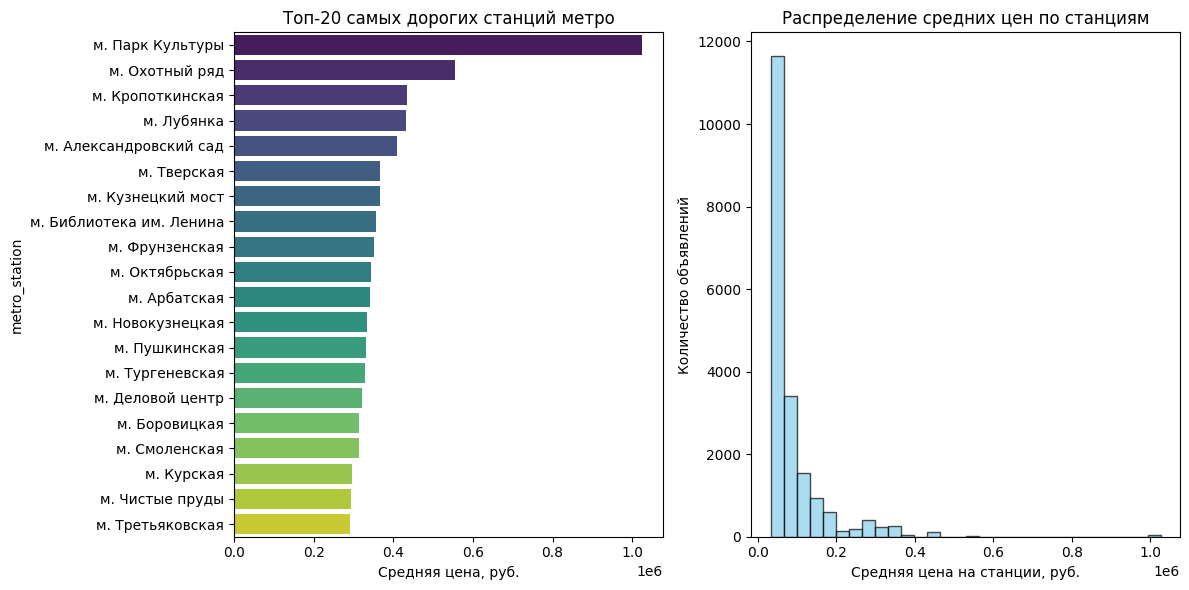


Статистика Target Encoding для метро:
  Средняя цена по всем станциям: 87,209 руб.
  Минимальная средняя цена: 32,663 руб.
  Максимальная средняя цена: 1,025,595 руб.
  Стандартное отклонение: 84,232 руб.


In [25]:
# Визуализация распределения цен по станциям метро
if 'metro_station_encoded' in df_encoded.columns:
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    # Топ-20 самых дорогих станций
    metro_stats = df_encoded.groupby(df_new['metro_station'])['price_rub'].mean().sort_values(ascending=False).head(20)
    sns.barplot(y=metro_stats.index, x=metro_stats.values, palette='viridis')
    plt.title('Топ-20 самых дорогих станций метро')
    plt.xlabel('Средняя цена, руб.')

    plt.subplot(1, 2, 2)
    # Распределение закодированных значений
    plt.hist(df_encoded['metro_station_encoded'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title('Распределение средних цен по станциям')
    plt.xlabel('Средняя цена на станции, руб.')
    plt.ylabel('Количество объявлений')

    plt.tight_layout()
    plt.show()

    print(f"\nСтатистика Target Encoding для метро:")
    print(f"  Средняя цена по всем станциям: {df_encoded['metro_station_encoded'].mean():,.0f} руб.")
    print(f"  Минимальная средняя цена: {df_encoded['metro_station_encoded'].min():,.0f} руб.")
    print(f"  Максимальная средняя цена: {df_encoded['metro_station_encoded'].max():,.0f} руб.")
    print(f"  Стандартное отклонение: {df_encoded['metro_station_encoded'].std():,.0f} руб.")

In [27]:
# Функция для расчета MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    """
    Calculate Mean Absolute Percentage Error (MAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Избегаем деления на ноль
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def calculate_all_metrics(y_true, y_pred, model_name=""):
    """
    Calculate all evaluation metrics with focus on MAPE
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    metrics = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape
    }

    if model_name:
        print(f"\n{model_name} Metrics:")
        print(f"  MAPE: {mape:.2f}%")
        print(f"  R²: {r2:.4f}")
        print(f"  RMSE: {rmse:.2f}")
        print(f"  MAE: {mae:.2f}")

    return metrics

In [28]:
# Убедимся, что цена - наша целевая переменная
print("Колонки в датасете:")
print(df_encoded.columns.tolist())

# Разделяем на признаки и целевую переменную
X = df_encoded.drop(['price_rub', 'ad_id'], axis=1)  # Исключаем цену и ID
y = df_encoded['price_rub']

print(f"\nПризнаки (X): {X.shape}")
print(f"Целевая переменная (y): {y.shape}")

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"\nОбучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Колонки в датасете:
['ad_id', 'renovation', 'balcony', 'ceiling_height', 'garbage_chute', 'total_area', 'living_area', 'kitchen_area', 'rooms_count', 'rooms_description', 'metro_time_min', 'transport_type', 'building_type', 'floor', 'total_floors', 'parking_type', 'price_rub', 'loggia', 'windows_street', 'windows_yard', 'bathroom_separate', 'bathroom_combined', 'elevator_passenger', 'elevator_cargo', 'metro_station_encoded', 'living_to_total_ratio', 'kitchen_to_total_ratio', 'floor_ratio', 'area_per_room']

Признаки (X): (19543, 27)
Целевая переменная (y): (19543,)

Обучающая выборка: (15634, 27)
Тестовая выборка: (3909, 27)


In [29]:
# Список моделей для тестирования
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf')
}

# Словарь для хранения результатов
results = {}

print("ОБУЧЕНИЕ МОДЕЛЕЙ С ФОКУСОМ НА MAPE")
print("=" * 60)

# Обучение и оценка каждой модели
for name, model in models.items():
    print(f"\nОбучение модели: {name}")

    try:
        # Обучение модели
        model.fit(X_train, y_train)

        # Предсказания
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        # Расчет метрик
        metrics_train = calculate_all_metrics(y_train, y_pred_train)
        metrics_test = calculate_all_metrics(y_test, y_pred_test, name)

        # Кросс-валидация по MAPE
        def mape_scorer(estimator, X, y):
            y_pred = estimator.predict(X)
            return -mean_absolute_percentage_error(y, y_pred)  # отрицательное, т.к. чем меньше - тем лучше

        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring=mape_scorer)

        # Сохранение результатов
        results[name] = {
            'model': model,
            'metrics_train': metrics_train,
            'metrics_test': metrics_test,
            'cv_mape_mean': -cv_scores.mean(),  # возвращаем к положительному значению
            'cv_mape_std': cv_scores.std(),
            'predictions_test': y_pred_test
        }

        print(f"  Cross-val MAPE: {-cv_scores.mean():.2f}% (+/- {cv_scores.std() * 2:.2f}%)")

    except Exception as e:
        print(f"  Ошибка при обучении {name}: {e}")

ОБУЧЕНИЕ МОДЕЛЕЙ С ФОКУСОМ НА MAPE

Обучение модели: Linear Regression

Linear Regression Metrics:
  MAPE: 35.77%
  R²: 0.6979
  RMSE: 70925.92
  MAE: 28081.37
  Cross-val MAPE: 35.60% (+/- 3.03%)

Обучение модели: Ridge

Ridge Metrics:
  MAPE: 35.77%
  R²: 0.6979
  RMSE: 70927.33
  MAE: 28081.72
  Cross-val MAPE: 35.60% (+/- 3.03%)

Обучение модели: Lasso

Lasso Metrics:
  MAPE: 35.77%
  R²: 0.6979
  RMSE: 70926.27
  MAE: 28081.08
  Cross-val MAPE: 35.60% (+/- 3.03%)

Обучение модели: Random Forest

Random Forest Metrics:
  MAPE: 18.50%
  R²: 0.8543
  RMSE: 49262.84
  MAE: 17271.44
  Cross-val MAPE: 18.84% (+/- 3.74%)

Обучение модели: Gradient Boosting

Gradient Boosting Metrics:
  MAPE: 21.60%
  R²: 0.8157
  RMSE: 55394.43
  MAE: 19955.84
  Cross-val MAPE: 20.57% (+/- 3.97%)

Обучение модели: XGBoost

XGBoost Metrics:
  MAPE: 17.61%
  R²: 0.8621
  RMSE: 47921.93
  MAE: 17308.03
  Cross-val MAPE: 18.18% (+/- 3.63%)

Обучение модели: SVR

SVR Metrics:
  MAPE: 37.26%
  R²: -0.0837
  RM

In [30]:
# Создаем DataFrame с результатами
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'MAPE_Test (%)': [results[name]['metrics_test']['MAPE'] for name in results.keys()],
    'MAPE_Train (%)': [results[name]['metrics_train']['MAPE'] for name in results.keys()],
    'MAPE_CV (%)': [results[name]['cv_mape_mean'] for name in results.keys()],
    'R2_Test': [results[name]['metrics_test']['R2'] for name in results.keys()],
    'RMSE_Test': [results[name]['metrics_test']['RMSE'] for name in results.keys()],
    'MAE_Test': [results[name]['metrics_test']['MAE'] for name in results.keys()]
}).sort_values('MAPE_Test (%)')

print("\nСРАВНЕНИЕ МОДЕЛЕЙ (отсортировано по MAPE на тесте)")
print("=" * 70)
print(results_df.round(4))


СРАВНЕНИЕ МОДЕЛЕЙ (отсортировано по MAPE на тесте)
               Model  MAPE_Test (%)  MAPE_Train (%)  MAPE_CV (%)  R2_Test  \
5            XGBoost        17.6091         11.2760      18.1798   0.8621   
3      Random Forest        18.5028          6.7314      18.8360   0.8543   
4  Gradient Boosting        21.6027         19.2072      20.5729   0.8157   
2              Lasso        35.7716         35.3578      35.6029   0.6979   
0  Linear Regression        35.7725         35.3587      35.6044   0.6979   
1              Ridge        35.7731         35.3590      35.6046   0.6979   
6                SVR        37.2556         36.3174      36.3790  -0.0837   

     RMSE_Test    MAE_Test  
5   47921.9305  17308.0258  
3   49262.8436  17271.4422  
4   55394.4295  19955.8382  
2   70926.2685  28081.0842  
0   70925.9250  28081.3676  
1   70927.3270  28081.7249  
6  134329.3397  50276.3916  


/tmp/ipython-input-2124967622.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='MAPE_Test (%)', y='Model', palette='viridis')
/tmp/ipython-input-2124967622.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='R2_Test', y='Model', palette='viridis')
/tmp/ipython-input-2124967622.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='MAPE_CV (%)', y='Model', palette='viridis')
/tmp/ipython-input-2124967622.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated

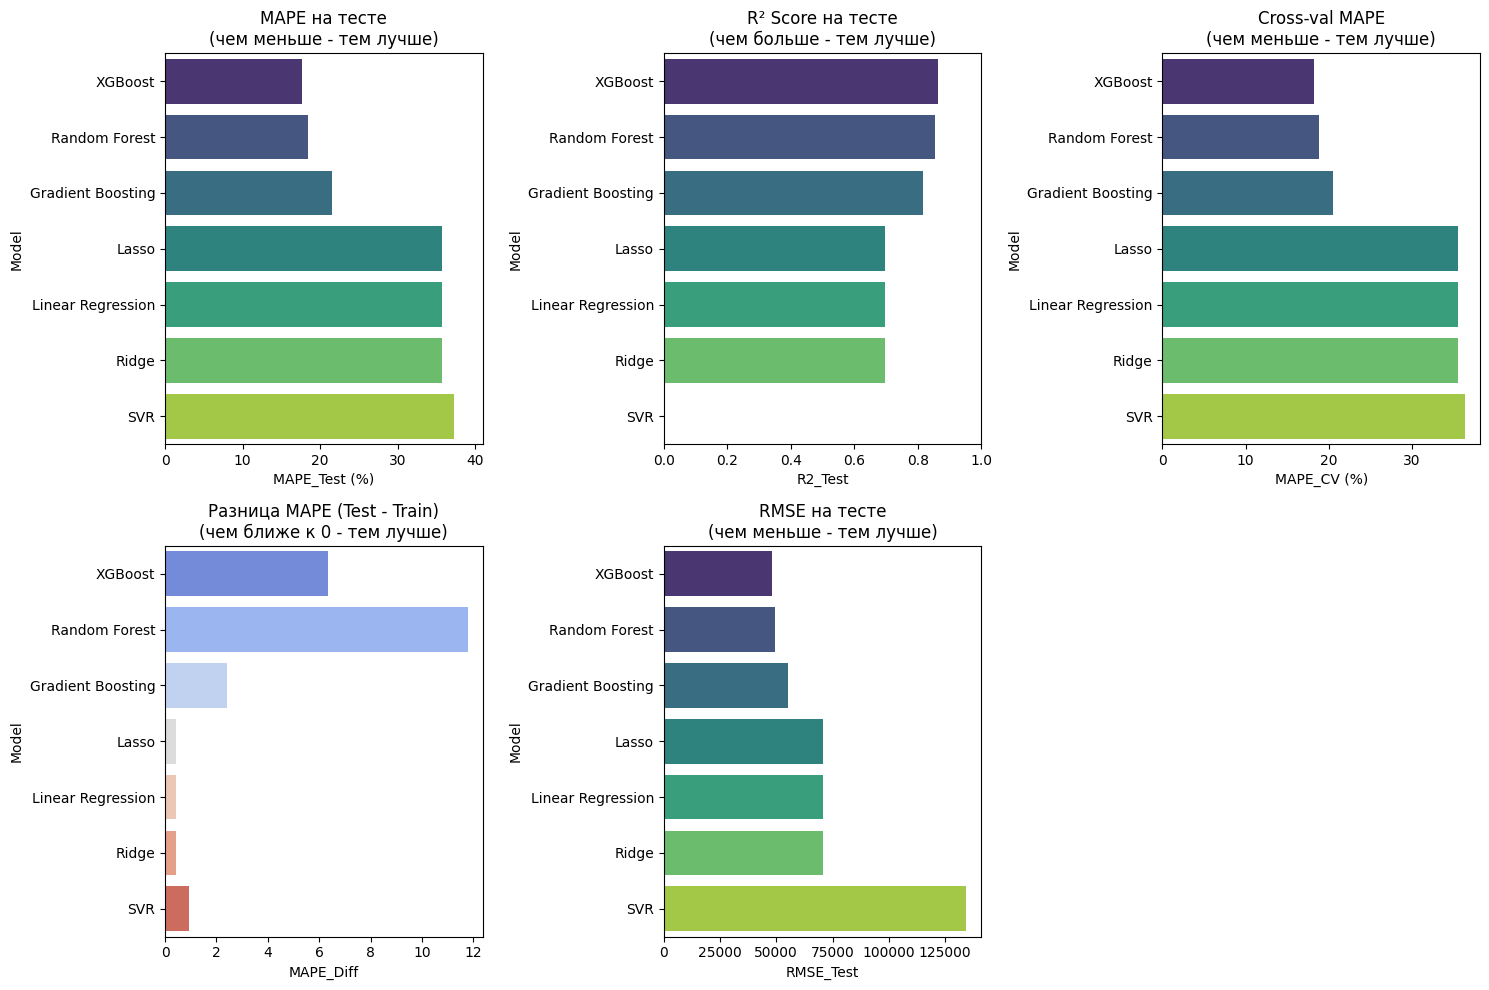

In [31]:
# Визуализация сравнения моделей
plt.figure(figsize=(15, 10))

# MAPE - основная метрика
plt.subplot(2, 3, 1)
sns.barplot(data=results_df, x='MAPE_Test (%)', y='Model', palette='viridis')
plt.title('MAPE на тесте\n(чем меньше - тем лучше)')
plt.xlim(0, results_df['MAPE_Test (%)'].max() * 1.1)

# R² scores
plt.subplot(2, 3, 2)
sns.barplot(data=results_df, x='R2_Test', y='Model', palette='viridis')
plt.title('R² Score на тесте\n(чем больше - тем лучше)')
plt.xlim(0, 1)

# Cross-validation MAPE
plt.subplot(2, 3, 3)
sns.barplot(data=results_df, x='MAPE_CV (%)', y='Model', palette='viridis')
plt.title('Cross-val MAPE\n(чем меньше - тем лучше)')

# Разница между train и test MAPE (переобучение)
results_df['MAPE_Diff'] = results_df['MAPE_Test (%)'] - results_df['MAPE_Train (%)']
plt.subplot(2, 3, 4)
sns.barplot(data=results_df, x='MAPE_Diff', y='Model', palette='coolwarm')
plt.title('Разница MAPE (Test - Train)\n(чем ближе к 0 - тем лучше)')

# RMSE
plt.subplot(2, 3, 5)
sns.barplot(data=results_df, x='RMSE_Test', y='Model', palette='viridis')
plt.title('RMSE на тесте\n(чем меньше - тем лучше)')

plt.tight_layout()
plt.show()


ДЕТАЛЬНЫЙ АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ: XGBoost
MAPE: 17.61%
R²: 0.8621
RMSE: 47921.93
MAE: 17308.03

Интерпретация MAPE: 👍 ХОРОШАЯ точность
Средняя ошибка предсказания: ±17.6% от реальной цены


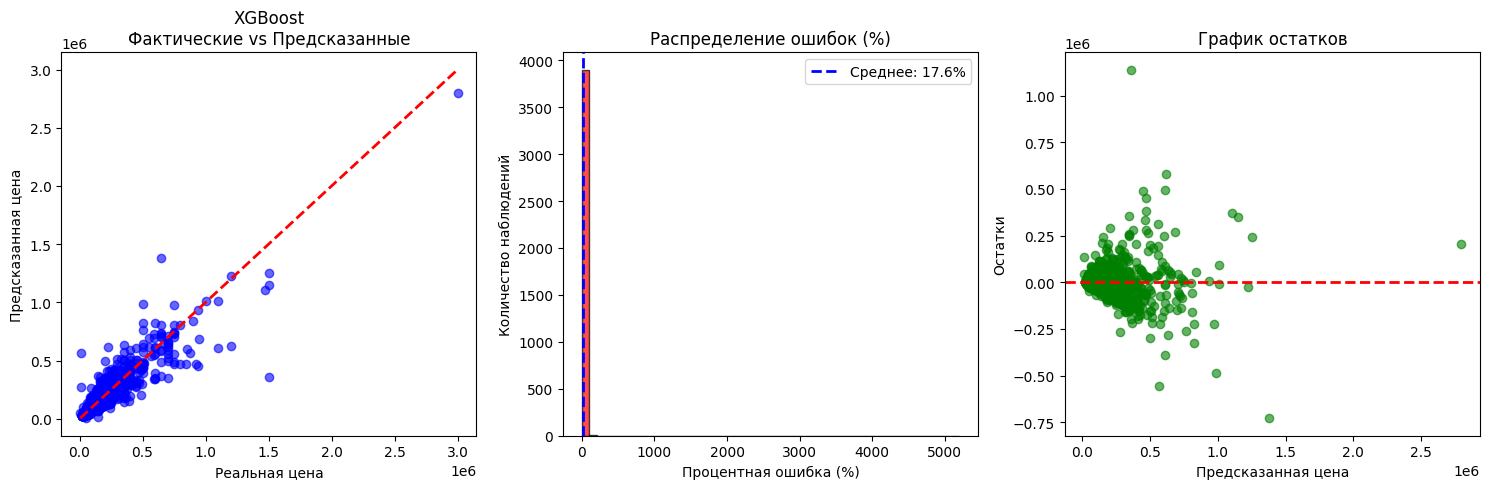


Статистика процентных ошибок:
  Средняя ошибка (MAPE): 17.61%
  Медианная ошибка: 11.20%
  75% перцентиль ошибок: 20.49%
  90% перцентиль ошибок: 32.49%
  Максимальная ошибка: 5202.94%


In [32]:
# Выбираем лучшую модель по MAPE на тесте
best_model_name = results_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
best_predictions = results[best_model_name]['predictions_test']
best_metrics = results[best_model_name]['metrics_test']

print(f"\n{'='*60}")
print(f"ДЕТАЛЬНЫЙ АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ: {best_model_name}")
print(f"{'='*60}")

print(f"MAPE: {best_metrics['MAPE']:.2f}%")
print(f"R²: {best_metrics['R2']:.4f}")
print(f"RMSE: {best_metrics['RMSE']:.2f}")
print(f"MAE: {best_metrics['MAE']:.2f}")

# Интерпретация MAPE
mape_value = best_metrics['MAPE']
if mape_value < 10:
    interpretation = "💪 ОТЛИЧНАЯ точность"
elif mape_value < 20:
    interpretation = "👍 ХОРОШАЯ точность"
elif mape_value < 30:
    interpretation = "✅ УДОВЛЕТВОРИТЕЛЬНАЯ точность"
elif mape_value < 50:
    interpretation = "⚠️ НИЗКАЯ точность"
else:
    interpretation = "❌ ОЧЕНЬ НИЗКАЯ точность"

print(f"\nИнтерпретация MAPE: {interpretation}")
print(f"Средняя ошибка предсказания: ±{mape_value:.1f}% от реальной цены")

# Графики для лучшей модели
plt.figure(figsize=(15, 5))

# 1. Фактические vs Предсказанные значения
plt.subplot(1, 3, 1)
plt.scatter(y_test, best_predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title(f'{best_model_name}\nФактические vs Предсказанные')

# 2. Распределение процентных ошибок
plt.subplot(1, 3, 2)
percentage_errors = np.abs((y_test - best_predictions) / y_test) * 100
plt.hist(percentage_errors, bins=50, alpha=0.7, color='red', edgecolor='black')
plt.axvline(percentage_errors.mean(), color='blue', linestyle='--', linewidth=2,
            label=f'Среднее: {percentage_errors.mean():.1f}%')
plt.xlabel('Процентная ошибка (%)')
plt.ylabel('Количество наблюдений')
plt.title('Распределение ошибок (%)')
plt.legend()

# 3. Остатки
plt.subplot(1, 3, 3)
residuals = y_test - best_predictions
plt.scatter(best_predictions, residuals, alpha=0.6, color='green')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Предсказанная цена')
plt.ylabel('Остатки')
plt.title('График остатков')

plt.tight_layout()
plt.show()

# Статистика ошибок
print(f"\nСтатистика процентных ошибок:")
print(f"  Средняя ошибка (MAPE): {percentage_errors.mean():.2f}%")
print(f"  Медианная ошибка: {np.median(percentage_errors):.2f}%")
print(f"  75% перцентиль ошибок: {np.percentile(percentage_errors, 75):.2f}%")
print(f"  90% перцентиль ошибок: {np.percentile(percentage_errors, 90):.2f}%")
print(f"  Максимальная ошибка: {percentage_errors.max():.2f}%")


ВАЖНОСТЬ ПРИЗНАКОВ ДЛЯ XGBoost:


/tmp/ipython-input-3340651327.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='rocket')


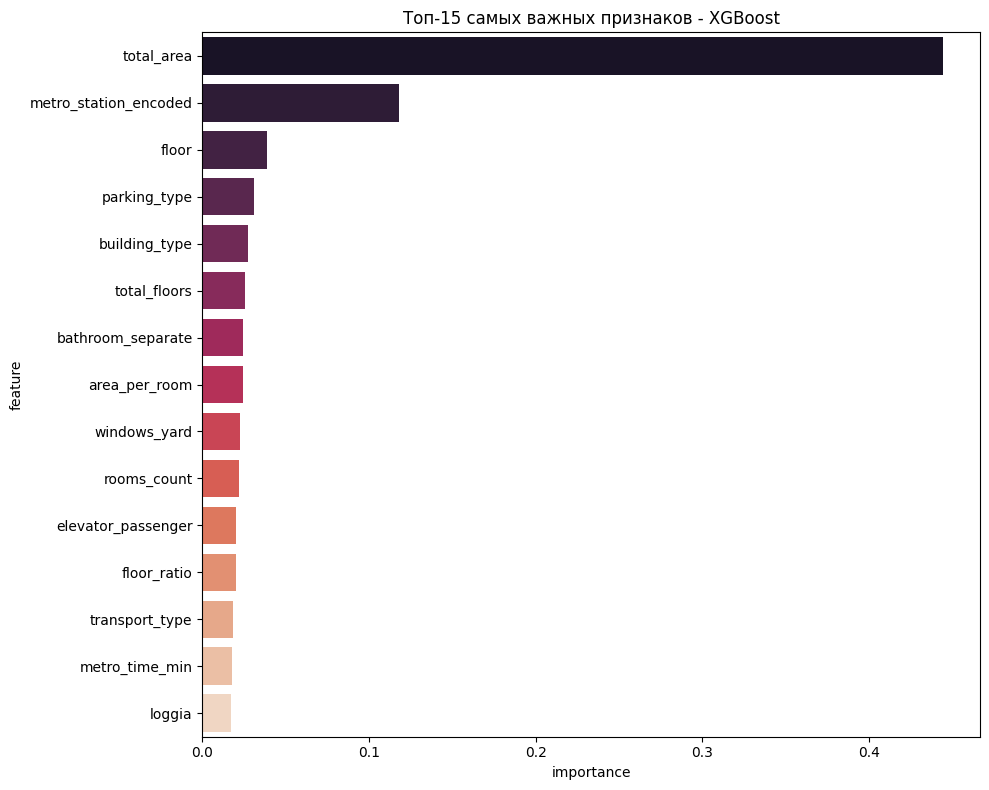

Топ-10 самых важных признаков:
  total_area: 0.4443
  metro_station_encoded: 0.1177
  floor: 0.0386
  parking_type: 0.0307
  building_type: 0.0274
  total_floors: 0.0254
  bathroom_separate: 0.0246
  area_per_room: 0.0242
  windows_yard: 0.0226
  rooms_count: 0.0219


In [33]:
# Анализ важности признаков для tree-based моделей
if hasattr(best_model, 'feature_importances_'):
    print(f"\nВАЖНОСТЬ ПРИЗНАКОВ ДЛЯ {best_model_name}:")

    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    # Визуализация топ-15 признаков
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='rocket')
    plt.title(f'Топ-15 самых важных признаков - {best_model_name}')
    plt.tight_layout()
    plt.show()

    print("Топ-10 самых важных признаков:")
    for i, row in feature_importance.head(10).iterrows():
        print(f"  {row['feature']}: {row['importance']:.4f}")

In [34]:
# Сохранение лучшей модели
model_filename = f'best_model_{best_model_name.replace(" ", "_").lower()}.pkl'
joblib.dump(best_model, model_filename)

# Сохранение всех результатов
joblib.dump(results, 'all_models_results.pkl')

print(f"\n💾 Модель сохранена как: {model_filename}")
print(f"💾 Все результаты сохранены как: 'all_models_results.pkl'")

# Сохранение предсказаний для анализа
predictions_df = pd.DataFrame({
    'actual_price': y_test,
    'predicted_price': best_predictions,
    'absolute_error': np.abs(y_test - best_predictions),
    'percentage_error': percentage_errors
})
predictions_df.to_csv('model_predictions.csv', index=False, encoding='utf-8-sig')
print(f"💾 Предсказания сохранены как: 'model_predictions.csv'")


💾 Модель сохранена как: best_model_xgboost.pkl
💾 Все результаты сохранены как: 'all_models_results.pkl'
💾 Предсказания сохранены как: 'model_predictions.csv'


In [35]:
print(f"\n{'='*70}")
print("ФИНАЛЬНЫЙ ОТЧЕТ ПО МОДЕЛИРОВАНИЮ")
print(f"{'='*70}")

print(f"🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"📊 MAPE: {best_metrics['MAPE']:.2f}%")
print(f"📈 R²: {best_metrics['R2']:.4f}")
print(f"🎯 Точность: {interpretation}")

print(f"\n📋 Сравнение всех моделей по MAPE:")
for i, row in results_df.iterrows():
    marker = "🏆" if i == 0 else "  "
    print(f"{marker} {row['Model']:20} MAPE: {row['MAPE_Test (%)']:6.2f}%")


ФИНАЛЬНЫЙ ОТЧЕТ ПО МОДЕЛИРОВАНИЮ
🏆 ЛУЧШАЯ МОДЕЛЬ: XGBoost
📊 MAPE: 17.61%
📈 R²: 0.8621
🎯 Точность: 👍 ХОРОШАЯ точность

📋 Сравнение всех моделей по MAPE:
   XGBoost              MAPE:  17.61%
   Random Forest        MAPE:  18.50%
   Gradient Boosting    MAPE:  21.60%
   Lasso                MAPE:  35.77%
🏆 Linear Regression    MAPE:  35.77%
   Ridge                MAPE:  35.77%
   SVR                  MAPE:  37.26%
